In [1]:

%pip install seaborn

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns




[notice] A new release of pip is available: 23.2.1 -> 26.0.1
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


In [2]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("enrique4/activity-recognition-with-accelerometer-and-sound")

print("Path to dataset files:", path)

data = pd.read_csv(path + '/features.csv')

data.head()

/workspaces/CS156-Intro-To-AI-Project/venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Path to dataset files: /home/codespace/.cache/kagglehub/datasets/enrique4/activity-recognition-with-accelerometer-and-sound/versions/1


,userid,label,v1_mfcc1,v1_mfcc2,v1_mfcc3,v1_mfcc4,v1_mfcc5,v1_mfcc6,v1_mfcc7,v1_mfcc8,...,v2_maxX,v2_maxY,v2_maxZ,v2_corXY,v2_corXZ,v2_corYZ,v2_meanMagnitude,v2_sdMagnitude,v2_auc,v2_meanDif
0,user1,watch_tv,120.078886,3.025171,0.390508,-1.777848,-9.216060,-6.567632,-9.918761,-9.145534,...,0.097412,1.088135,0.227051,0.900163,-0.729511,-0.863478,1.014805,0.060424,70.021543,-0.000364
1,user1,watch_tv,130.243139,2.552278,-6.457879,-7.440159,-3.070106,-3.475476,-5.718819,-2.878174,...,0.703613,1.424805,0.818115,-0.210431,0.319599,-0.722541,1.005713,0.162644,79.451303,-0.006234
2,user1,watch_tv,122.259209,1.970267,-8.980575,-10.222030,-3.564994,-2.496906,-5.584900,-6.730588,...,0.312500,0.972656,-0.070312,-0.018862,-0.093852,-0.305722,1.002809,0.006100,77.216317,0.000019
3,user1,watch_tv,122.609566,3.188740,-7.049397,-10.569875,-0.220824,-0.649459,-4.975825,-6.856288,...,0.349854,1.020020,-0.053223,0.492439,0.273064,-0.023051,1.002878,0.021292,75.215866,-0.000023
4,user1,watch_tv,121.393023,1.338798,-8.706183,-8.654997,-4.935310,-3.401656,-5.031361,-7.957924,...,0.322266,0.955078,-0.076904,-0.226296,-0.217439,-0.053895,1.003427,0.002849,71.243346,-0.000083


__1. Dataset Exploration__

In [3]:
user_row_count = data.groupby('userid').count()
print(user_row_count['label'])
print('Total Users: ', len(user_row_count))
print('Total Records ', len(data))

userid
user1    466
user2    466
user3    454
Name: label, dtype: int64
Total Users:  3
Total Records  1386


The home-tasks data were collected by 3 individuals. They were 1 female and
2 males with ages ranging from 25 to 30. The subjects were asked to perform
7 home-task activities including: mop floor, sweep floor, type on computer keyboard, brush teeth, wash hands, eat chips and watch TV. The eat chips activity
was conducted with a bag of chips. Each individual performed each activity for
approximately 3 minutes. If the activity lasted less than 3 minutes, an additional
trial was conducted until the 3 minutes were completed. The volunteers used a
wrist-band (Microsoft Band 2) and a smartphone (Sony XPERIA) to collect the
data.

In [4]:
summary_table = {
    'Users': [len(user_row_count)],
    'Days per participant (21 minutes each, 3 minutes per each activity, 7 activities)':[0.01458333333],
    'Demographic Diversity (Age and Gender)': ['2 males and 1 female, ages: 25-30'],
    'Total Labels': [f'{len(data)}, {len(data)/len(user_row_count)} per user']
}
summary_table = pd.DataFrame(summary_table)
summary_table

,Users,"Days per participant (21 minutes each, 3 minutes per each activity, 7 activities)",Demographic Diversity (Age and Gender),Total Labels
0,3,0.014583,"2 males and 1 female, ages: 25-30","1386, 462.0 per user"


In [5]:
pd.set_option('display.max_rows', None)
act_by_subject = data.groupby(['userid', 'label']).count()
act_by_subject['v2_meanDif']

userid  label           
user1   brush_teeth          59
        eat_chips           153
        mop_floor            56
        sweep                47
        type_on_keyboard     49
        wash_hands           36
        watch_tv             66
user2   brush_teeth          57
        eat_chips            65
        mop_floor            63
        sweep                68
        type_on_keyboard     63
        wash_hands           79
        watch_tv             71
user3   brush_teeth          64
        eat_chips            64
        mop_floor            62
        sweep                63
        type_on_keyboard     67
        wash_hands           65
        watch_tv             69
Name: v2_meanDif, dtype: int64

__2. Annotated Signal Exploration__

Does the data have missing values?  False


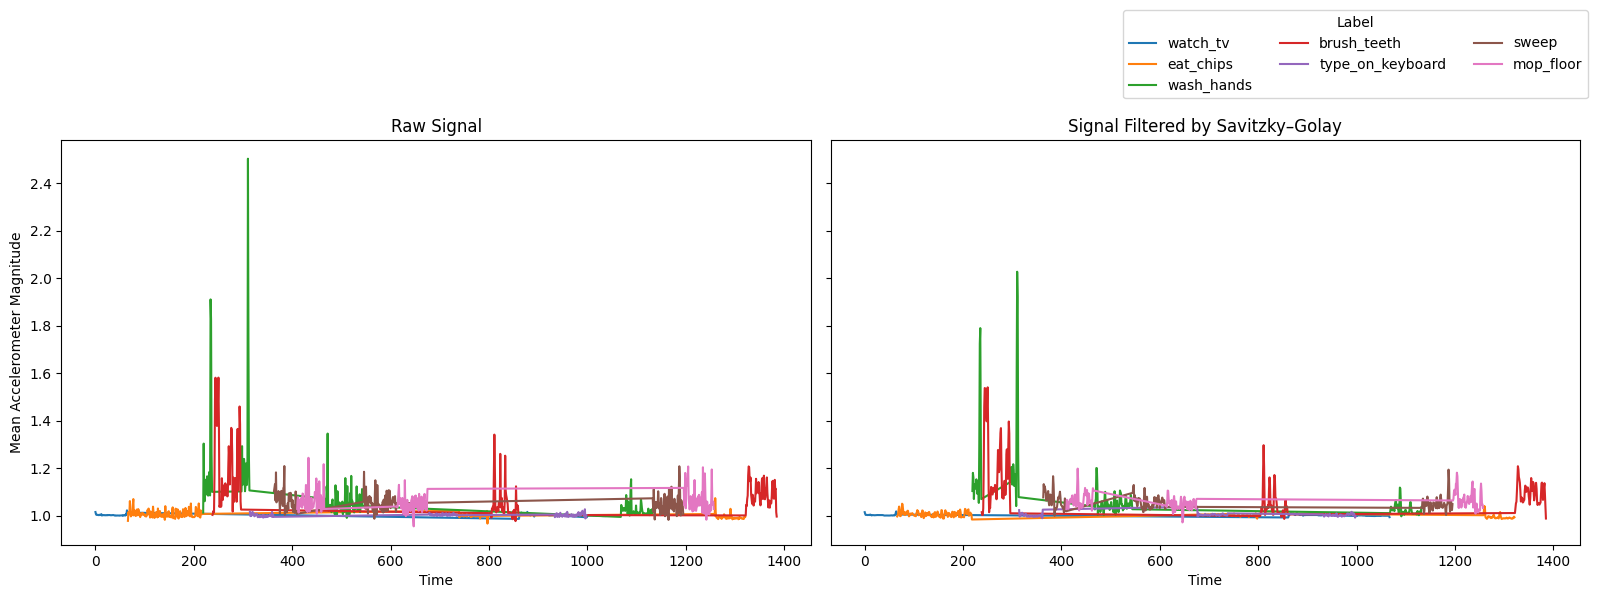

In [6]:
from scipy.signal import savgol_filter

has_missing_values = data.isna().any().any()
print('Does the data have missing values? ', has_missing_values)

filt = savgol_filter(data['v2_meanMagnitude'], window_length=5, polyorder=2)

fig, axes = plt.subplots(1, 2, figsize=(16, 5), sharey=True)
sns.lineplot(data=data, x=data.index, y='v2_meanMagnitude', hue='label', ax=axes[0]).set_title('Raw Signal')
sns.lineplot(data=data, x=data.index, y=filt, hue='label', ax=axes[1]).set_title('Signal Filtered by Savitzky–Golay')

axes[0].set_ylabel('Mean Accelerometer Magnitude')
axes[0].set_xlabel('Time')

axes[1].set_ylabel('Filtered Mean Accelerometer Magnitude')
axes[1].set_xlabel('Time')

handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles, labels, bbox_to_anchor=(1, 1.2), loc='upper right', ncol=3, title='Label')
axes[0].get_legend().remove()
axes[1].get_legend().remove()

plt.tight_layout()

__Narrative Explaining Raw Signal Patterns__  
Lorem Ipsum Dolor TO BE DONE

__3. Signal Preprocessing__

The raw accelerometer text files were processed to represent overall movement intensity. Time-doimain plots showed clear differences among activities. Watch TV was mostly stable with small fluctuations, indicating low movement. Eat chips showed frequent repeated fluctaions, suggesting moderate periodic hand motion. Wash hands exhibited largest and most irregular variations, indicating vigorous movement. Other activities such as brush teeth, sweep, and mop floor also showed larger variations than passive tasks. These visual differences suggest that preprocessing and feature extraction should be able to separate low-motion and high-motion activities.

In [7]:
from pathlib import Path

users = ["user1", "user2", "user3"]
files_by_user = {}

for user in users:
    data_dir = Path(path) / user
    files = {}
    for file in data_dir.glob("*-acc-*.txt"):
        activity = file.stem.split("-acc-")[-1]
        files[activity] = str(file)
    files_by_user[user] = files

files = files_by_user["user1"]
print({u: len(v) for u, v in files_by_user.items()})

{'user1': 7, 'user2': 7, 'user3': 7}


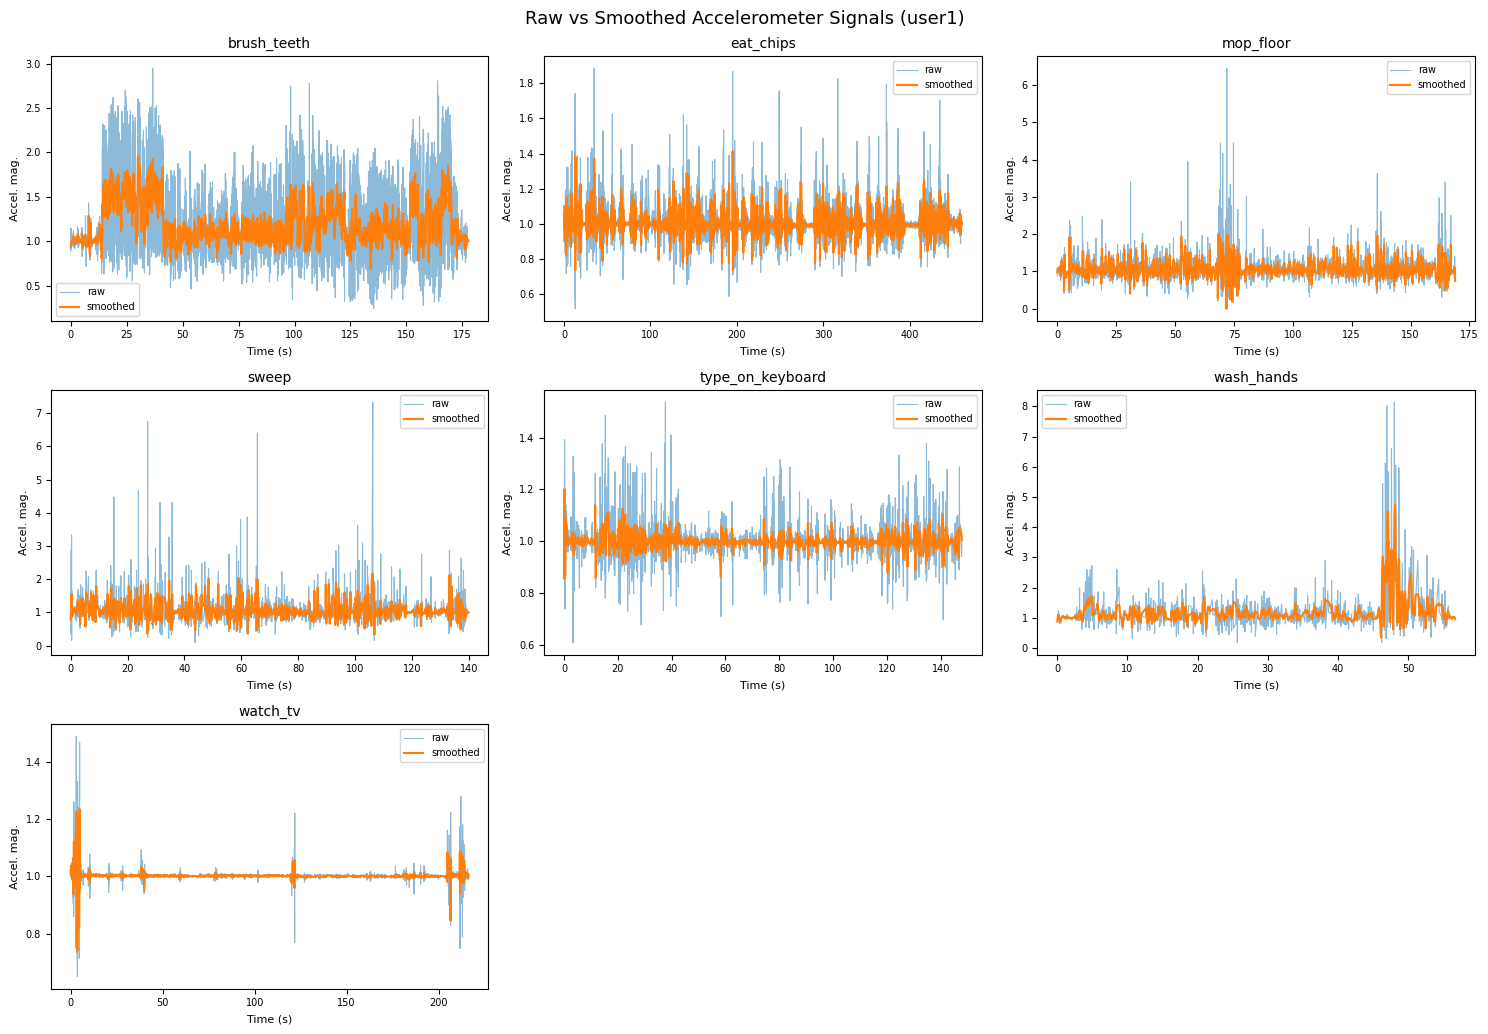

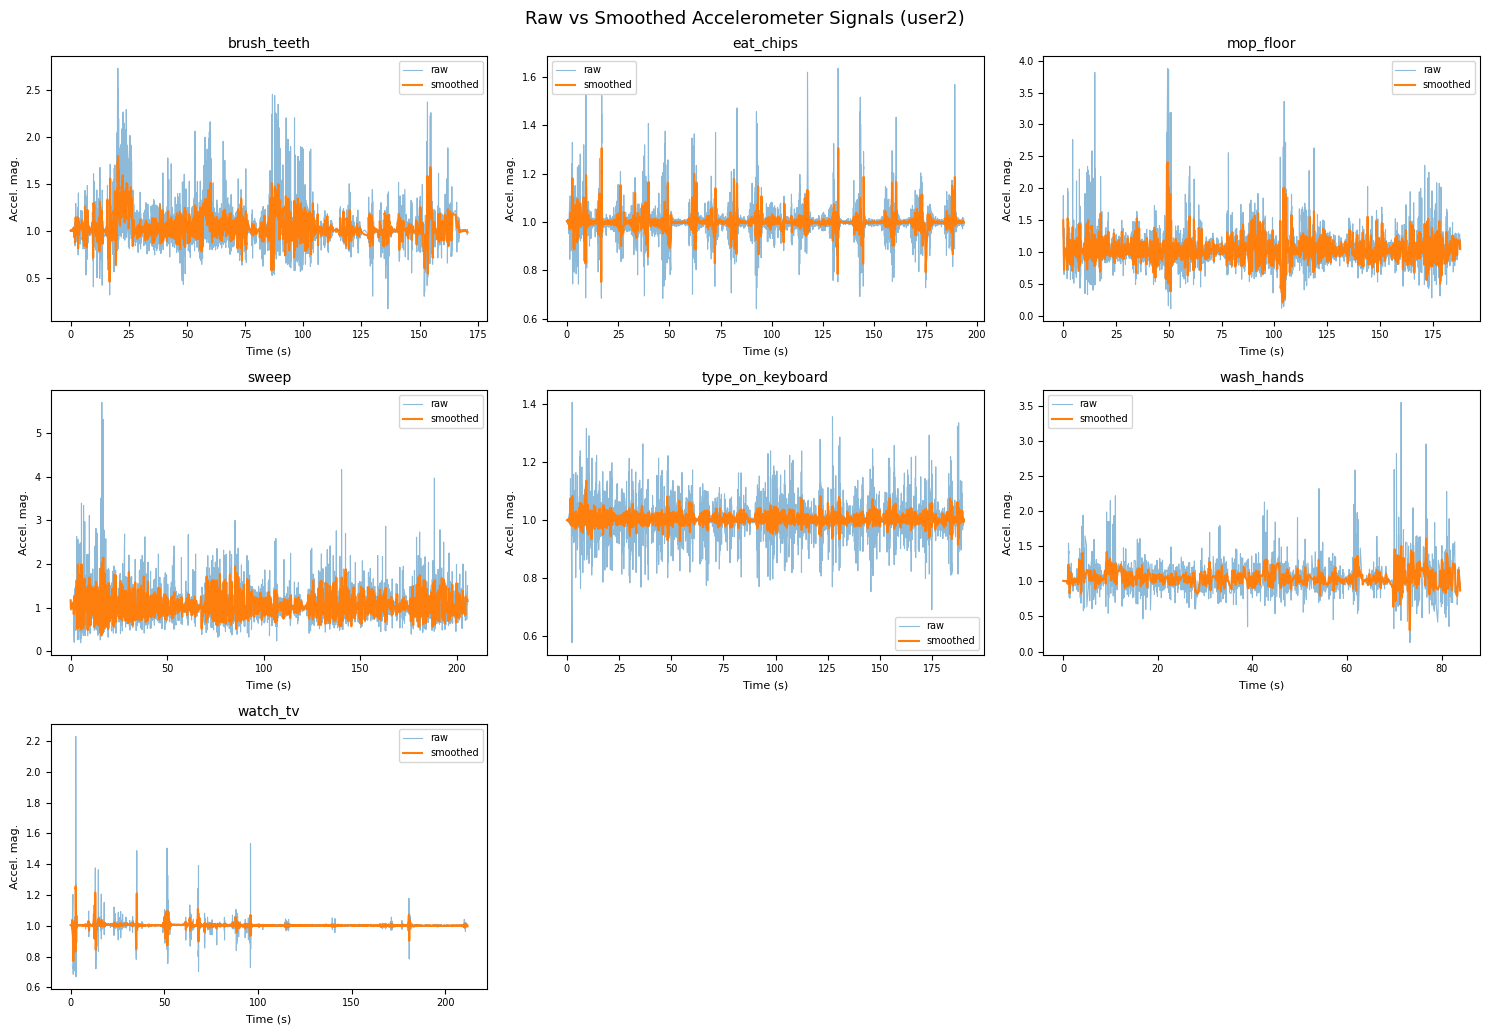

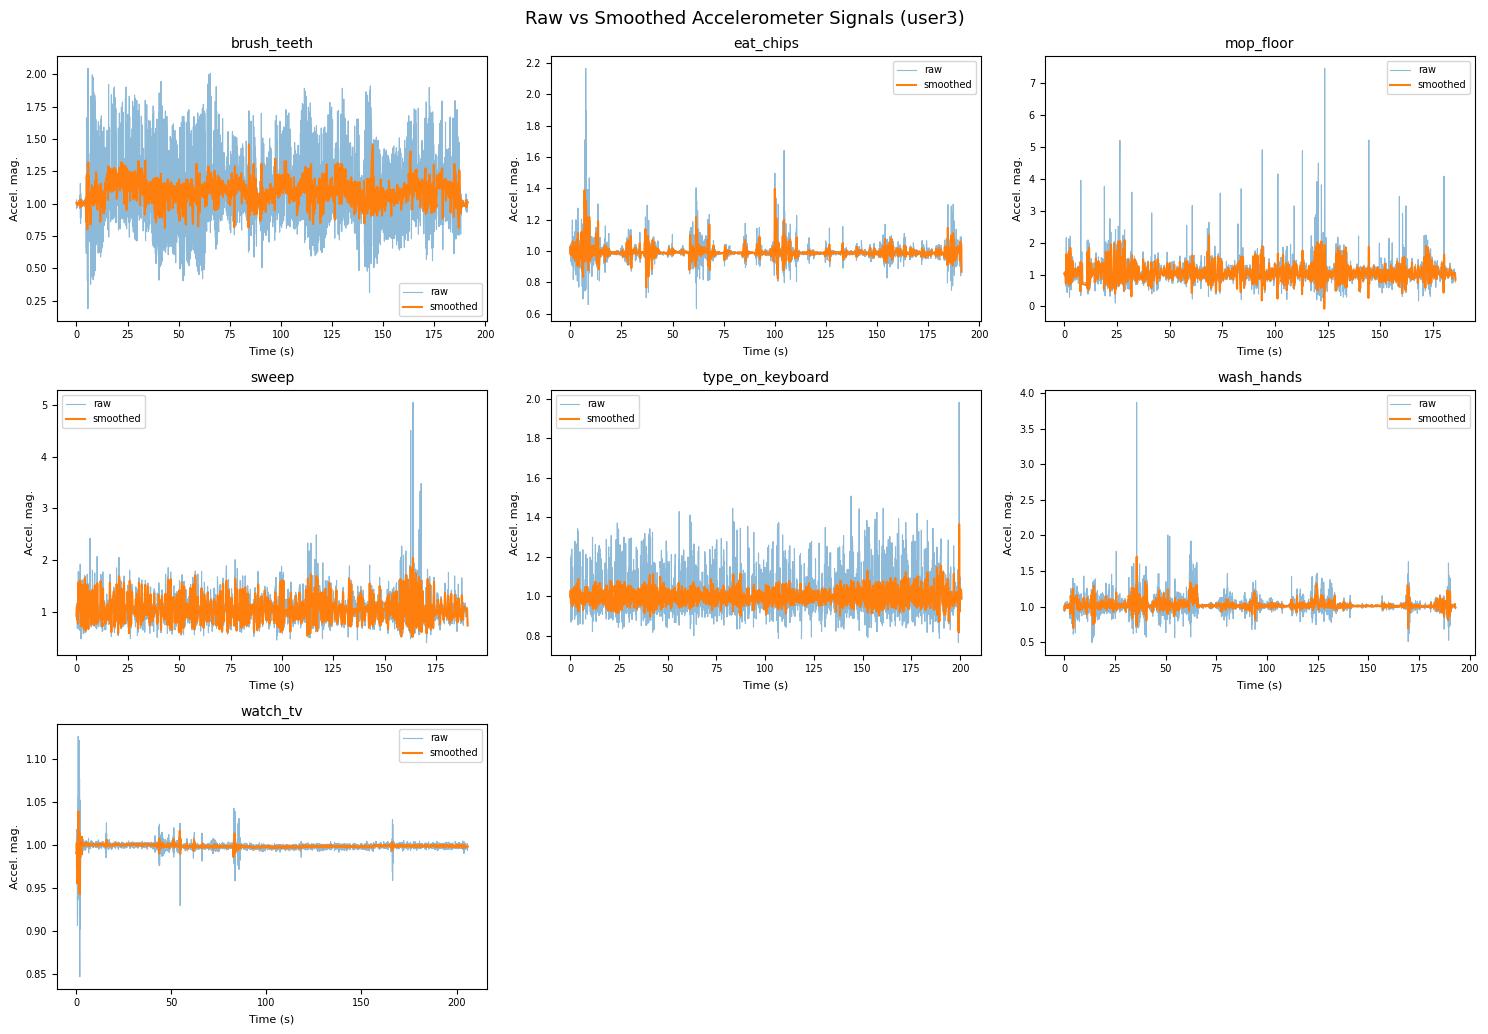

In [8]:
import math

#=================================
# Visualizing raw vs smoothed accelerometer data for 3 users
#=================================
def estimate_sampling_rate(df):
    dt = np.diff(df["time_sec"])
    dt = dt[dt > 0]  # Remove negative values
    fs = 1 / np.mean(dt)
    return fs

def preprocess_signal(df):
    df = df.copy()

    # Sort by time
    df = df.sort_values("time_sec").reset_index(drop=True)

    # Interpolate missing values
    for col in ["x", "y", "z", "magnitude"]:
        if df[col].isna().sum() > 0:
            df[col] = df[col].interpolate(method="linear").bfill().ffill()

    # Smooth signal
    fs = estimate_sampling_rate(df)
    win = int(fs * 0.5)
    if win % 2 == 0:
        win += 1
    win = max(5, win)
    if win >= len(df):
        win = len(df) - 1 if len(df) % 2 == 0 else len(df)

    df["x_smooth"] = savgol_filter(df["x"], window_length=win, polyorder=2)
    df["y_smooth"] = savgol_filter(df["y"], window_length=win, polyorder=2)
    df["z_smooth"] = savgol_filter(df["z"], window_length=win, polyorder=2)
    df["mag_smooth"] = savgol_filter(df["magnitude"], window_length=win, polyorder=2)
    return df

def load_acc_file(filepath):
    df = pd.read_csv(filepath, header=None, names=["timestamp", "x", "y", "z"])

    # Convert timestamp to relative seconds
    df["time_sec"] = (df["timestamp"] - df["timestamp"].iloc[0]) / 1000.0

    # Movement magnitude
    df["magnitude"] = np.sqrt(df["x"]**2 + df["y"]**2 + df["z"]**2)
    return df

# Build processed data per user
user_raw_data = {
    user: {label: preprocess_signal(load_acc_file(file_path)) for label, file_path in user_files.items()}
    for user, user_files in files_by_user.items()
}

for user in users:
    labels = sorted(user_raw_data[user].keys())
    n = len(labels)
    cols = 3
    rows = math.ceil(n / cols)
    fig, axes = plt.subplots(rows, cols, figsize=(5 * cols, 3.5 * rows))
    axes = axes.flatten()

    for idx, label in enumerate(labels):
        ax = axes[idx]
        df = user_raw_data[user][label]
        ax.plot(df["time_sec"], df["magnitude"], label="raw", alpha=0.5, linewidth=0.8)
        ax.plot(df["time_sec"], df["mag_smooth"], label="smoothed", linewidth=1.5)
        ax.set_title(label, fontsize=10)
        ax.set_xlabel("Time (s)", fontsize=8)
        ax.set_ylabel("Accel. mag.", fontsize=8)
        ax.tick_params(labelsize=7)
        ax.legend(fontsize=7)

    # Hide unused subplots
    for idx in range(n, len(axes)):
        axes[idx].set_visible(False)

    fig.suptitle(f"Raw vs Smoothed Accelerometer Signals ({user})", fontsize=13)
    plt.tight_layout()
    plt.show()

The raw accelerometer signals are noisy and uneven, so direct interpretation is difficult. Short spikes, sensor jitter, and minor recording inconsistencies can mask the true motion pattern of each activity. After converting timestamps to a consistent time scale, handling missing values, and applying smoothing, the signals become more stable and easier to interpret.

These plots show two useful findings for the task. First, activities are reasonably distinguishable: low-motion actions (such as watch TV) remain relatively flat, while more active tasks (such as wash hands, sweep, and mop floor) show larger variability and stronger fluctuations. Second, the same activity still exhibits user-specific differences in amplitude and temporal pattern, indicating inter-user variability. This supports using robust feature extraction and normalization before model training.

__4. Windowing Strategies__

In [9]:
window_sizes = [0.5, 1.0, 1.5, 2.0, 2.5, 3.0, 3.5, 4.0, 4.5, 5.0]

def normalized_energy(x):
    x = np.asarray(x)
    return np.mean(x**2)

energy_results = {}

for user in users:
    raw_data = user_raw_data[user]
    results = []
    for label, df in raw_data.items():
        fs = estimate_sampling_rate(df)
        signal = df["mag_smooth"].values
        n_samples = len(signal)

        # Iterate over window sizes
        for w in window_sizes:
            window_size = int(w * fs)
            step_size = int(window_size * 0.5)   # 50% overlap

            window_energies = []

            # Compute window energies
            if window_size > 1 and step_size > 0 and n_samples >= window_size:
                for start in range(0, n_samples - window_size + 1, step_size):
                    window = signal[start:start + window_size]
                    window_energies.append(normalized_energy(window))

            # Compute CV
            if len(window_energies) > 0:
                mean_window_energy = np.mean(window_energies)
                std_window_energy = np.std(window_energies)
                cv_energy = std_window_energy / mean_window_energy if mean_window_energy != 0 else np.nan
            else:
                mean_window_energy = np.nan
                std_window_energy = np.nan
                cv_energy = np.nan

            results.append({
                "activity": label,
                "window_sec": w,
                "window_samples": window_size,
                "num_windows": len(window_energies),
                "cv_energy": cv_energy
            })

    energy_results[user] = pd.DataFrame(results)

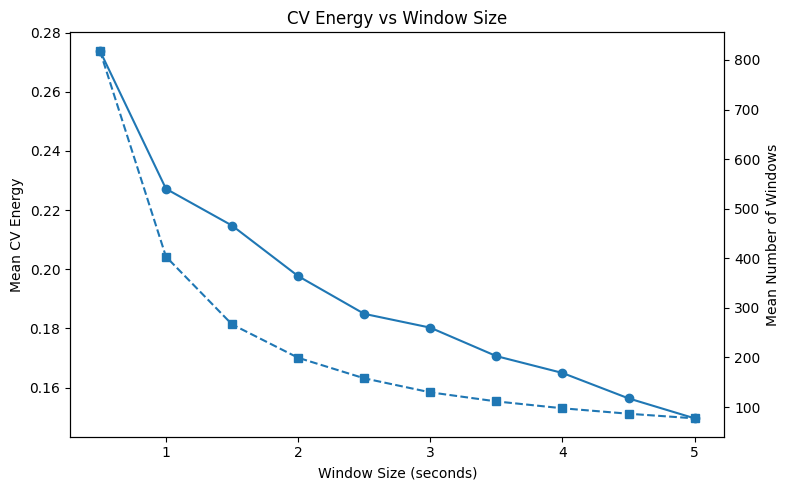

,window_sec,cv_energy,num_windows
0,0.5,0.2739,818.5714
1,1.0,0.2272,403.2857
2,1.5,0.2148,266.7143
3,2.0,0.1977,199.4286
4,2.5,0.1850,158.0000
5,3.0,0.1803,129.7143
6,3.5,0.1707,111.4286
7,4.0,0.1650,97.5714
8,4.5,0.1564,86.5714
9,5.0,0.1496,77.2857


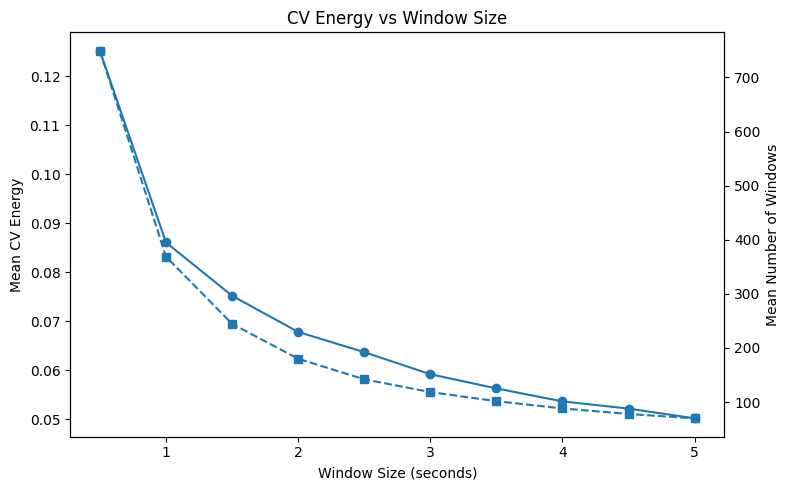

,window_sec,cv_energy,num_windows
0,0.5,0.1252,749.4286
1,1.0,0.0861,368.8571
2,1.5,0.0752,244.5714
3,2.0,0.0678,180.0000
4,2.5,0.0637,142.0000
5,3.0,0.0592,118.4286
6,3.5,0.0563,101.5714
7,4.0,0.0536,88.1429
8,4.5,0.0522,77.8571
9,5.0,0.0502,69.8571


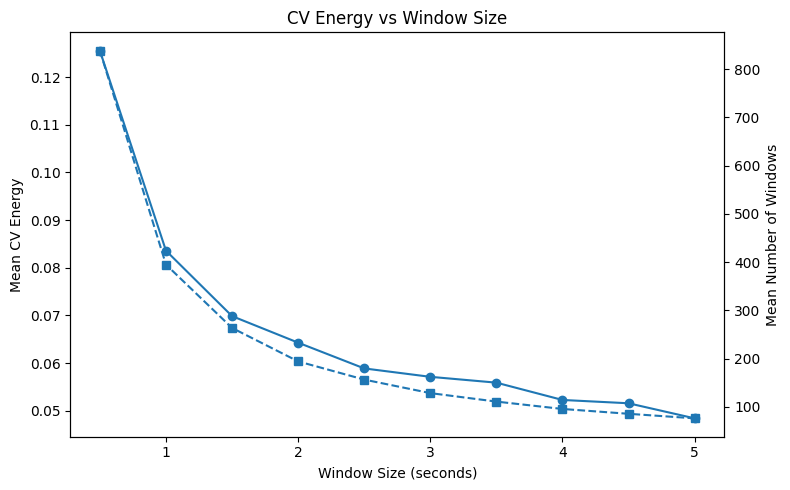

,window_sec,cv_energy,num_windows
0,0.5,0.1256,838.1429
1,1.0,0.0836,395.0000
2,1.5,0.0698,263.7143
3,2.0,0.0643,194.4286
4,2.5,0.0589,156.7143
5,3.0,0.0571,128.7143
6,3.5,0.0559,111.1429
7,4.0,0.0522,95.8571
8,4.5,0.0516,85.8571
9,5.0,0.0484,76.4286


In [11]:
for user in users:
    summary_plot = (
        energy_results[user].groupby("window_sec")[["cv_energy", "num_windows"]]
        .mean()
        .reset_index()
    )

    fig, ax1 = plt.subplots(figsize=(8, 5))

    ax1.plot(summary_plot["window_sec"], summary_plot["cv_energy"], marker="o")
    ax1.set_xlabel("Window Size (seconds)")
    ax1.set_ylabel("Mean CV Energy")
    ax1.set_title("CV Energy vs Window Size")

    ax2 = ax1.twinx()
    ax2.plot(summary_plot["window_sec"], summary_plot["num_windows"], marker="s", linestyle="--")
    ax2.set_ylabel("Mean Number of Windows")

    plt.tight_layout()
    plt.show()

    display(summary_plot.round(4))

Different window sizes from 0.5 to 5.0 seconds were evaluated using 50% overlap. For each window, normalized energy was computed, and stability was measured using the coefficient of variation (CV), defined as standard deviation divided by mean energy. Lower CV indicates more consistent energy across windows (more stable segmentation), while higher CV indicates greater variability in motion patterns.

Across activities and users, CV generally decreases as window size increases, indicating that larger windows produce more stable energy estimates. However, larger windows also reduce the number of available segments and can lower temporal sensitivity to short behavior changes. A 3-second window provides a practical balance: it substantially improves stability while preserving enough windows for reliable analysis and downstream modeling.

__5. Feature Extraction and Analysis__

In [12]:
from scipy.stats import entropy
# Feature Extraction from 3-second windows
WINDOW_SEC = 3.0
OVERLAP = 0.5   # 50% overlap

def zero_crossing_rate(x):
    x = np.asarray(x)
    x_centered = x - np.mean(x)   # center first so crossings are meaningful
    signs = np.sign(x_centered)
    signs[signs == 0] = 1
    return np.mean(signs[:-1] != signs[1:])

def spectral_entropy_from_power(power):
    power = np.asarray(power, dtype=float)
    power = power[power > 0]
    if len(power) == 0:
        return 0.0
    p = power / power.sum()
    return entropy(p, base=2)

def extract_window_features(signal, fs):
    signal = np.asarray(signal, dtype=float)

    #time domain features
    mean_val = np.mean(signal)
    sd_val = np.std(signal)
    rms_val = np.sqrt(np.mean(signal**2))
    zcr_val = zero_crossing_rate(signal)

    #frequency domain features
    detrended = signal - np.mean(signal)
    spectrum = np.fft.rfft(detrended)
    freqs = np.fft.rfftfreq(len(detrended), d=1/fs)
    power = np.abs(spectrum)**2

    if len(power) > 1:
        dominant_freq = freqs[1:][np.argmax(power[1:])]
    else:
        dominant_freq = 0.0

    spectral_energy = np.sum(power) / len(power)
    spectral_entropy = spectral_entropy_from_power(power)

    return {
        "mean": mean_val,
        "sd": sd_val,
        "rms": rms_val,
        "zcr": zcr_val,
        "dominant_freq": dominant_freq,
        "spectral_energy": spectral_energy,
        "spectral_entropy": spectral_entropy
    }

def build_feature_table(raw_data, window_sec=3.0, overlap=0.5):
    feature_rows = []

    for activity, df in raw_data.items():
        fs = estimate_sampling_rate(df)
        signal = df["mag_smooth"].values

        window_size = int(window_sec * fs)
        step_size = max(1, int(window_size * (1 - overlap)))

        if len(signal) < window_size:
            continue

        for start in range(0, len(signal) - window_size + 1, step_size):
            window = signal[start:start + window_size]
            feats = extract_window_features(window, fs)
            feats["activity"] = activity
            feature_rows.append(feats)

    return pd.DataFrame(feature_rows)

feature_df = build_feature_table(raw_data, window_sec=WINDOW_SEC, overlap=OVERLAP)

print("Feature table shape:", feature_df.shape)
display(feature_df.head())

Feature table shape: (901, 8)


,mean,sd,rms,zcr,dominant_freq,spectral_energy,spectral_entropy,activity
0,1.000680,0.012635,1.000759,0.133333,2.02626,0.011821,3.339870,brush_teeth
1,1.000777,0.012859,1.000859,0.133333,2.02626,0.012244,3.195759,brush_teeth
2,1.017433,0.077270,1.020363,0.093333,1.35084,0.443177,3.517706,brush_teeth
3,1.050046,0.108232,1.055609,0.160000,1.01313,0.869631,3.222147,brush_teeth
4,1.059465,0.081273,1.062578,0.200000,0.67542,0.489799,3.359658,brush_teeth


In [13]:
# Average feature values by activity
feature_cols = [
    "mean", "sd", "rms", "zcr",
    "dominant_freq", "spectral_energy", "spectral_entropy"
]

summary_by_activity = feature_df.groupby("activity")[feature_cols].mean().round(4)
display(summary_by_activity)

,mean,sd,rms,zcr,dominant_freq,spectral_energy,spectral_entropy
activity,,,,,,,
brush_teeth,1.0936,0.0641,1.0956,0.2181,1.7123,0.3357,3.3581
eat_chips,0.9939,0.0254,0.9946,0.1315,1.1686,0.1018,2.8534
mop_floor,1.0694,0.2177,1.0946,0.0958,1.0070,4.2913,2.5491
sweep,1.0496,0.2092,1.0715,0.0813,0.8182,3.4972,2.1947
type_on_keyboard,1.0021,0.0309,1.0026,0.1833,1.7552,0.0835,3.1982
wash_hands,1.0235,0.0411,1.0249,0.1383,1.2291,0.2268,2.8831
watch_tv,0.9991,0.0011,0.9991,0.2064,1.1447,0.0004,3.3642


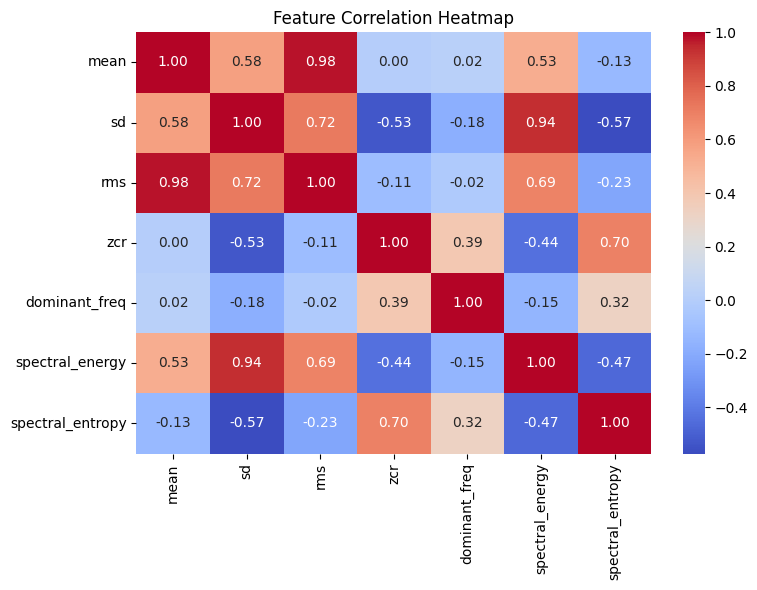

In [14]:
# Correlation analysis (heatmap)
corr_matrix = feature_df[feature_cols].corr()

plt.figure(figsize=(8, 6))
sns.heatmap(corr_matrix, annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Feature Correlation Heatmap")
plt.tight_layout()
plt.show()

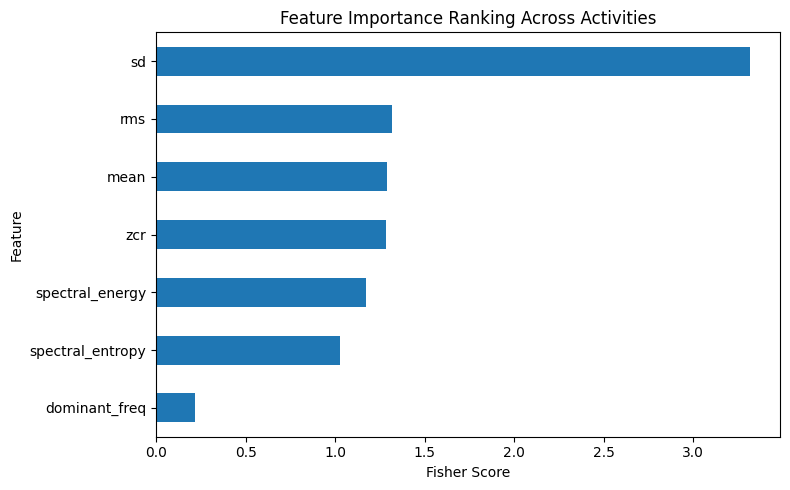

,fisher_score
sd,3.318217
rms,1.316222
mean,1.288516
zcr,1.286511
spectral_energy,1.170779
spectral_entropy,1.026674
dominant_freq,0.219244


In [15]:
# Feature importance ranking
# Using multiclass Fisher Score
def fisher_score_multiclass(X, y):
    scores = {}
    overall_mean = X.mean()

    for col in X.columns:
        numerator = 0.0
        denominator = 0.0

        for cls in sorted(y.unique()):
            x_c = X.loc[y == cls, col]
            n_c = len(x_c)
            mu_c = x_c.mean()
            var_c = x_c.var(ddof=0)

            numerator += n_c * (mu_c - overall_mean[col])**2
            denominator += n_c * var_c

        scores[col] = numerator / denominator if denominator != 0 else 0.0

    return pd.Series(scores).sort_values(ascending=False)

fisher_scores = fisher_score_multiclass(feature_df[feature_cols], feature_df["activity"])

plt.figure(figsize=(8, 5))
fisher_scores.sort_values().plot(kind="barh")
plt.xlabel("Fisher Score")
plt.ylabel("Feature")
plt.title("Feature Importance Ranking Across Activities")
plt.tight_layout()
plt.show()

display(fisher_scores.rename("fisher_score").to_frame())

For feature extract, we extracted both time-domain and frequency-domain features from the smoothed accelerometer magnitude signal using 3-second windows with 50% overlap. The time-domain features were mean, standard deviation, root mean square (RMS), and zero-crossing rate (ZCR). These describe the overall intensity, variability, signal power, and amount of directional fluctuation in motion. The frequency-domain features were dominant frequency, spectral energy, and spectral entropy, which capture periodicity, strength of oscillation, and complexity of motion patterns.

The correlation heatmap helps show which features provide similar information. In general, RMS and spectral energy are often strongly related because both reflect signal strength, while standard deviation also tends to increase for more vigorous activities. Features (like dominant frequency) and (spectral entropy) are useful because they capture different aspects of movement that are not fully explained by signal magnitude alone.

The feature-importance ranking shows which features are most helpful for separating activities. Higher-ranked features contribute more strongly to distinguishing passive activities such as watching TV from repetitive actions such as brushing teeth, sweeping, or mopping. In particular, variability based and energy based features are expected to be strong because active tasks produce larger and less stable motion signals, while frequency-based features help identify repeated movement patterns.
Overall, combining time-domain and frequency-domain features gives a more complete representation of human activity than using either type alone.

__6. Modeling__


=== Decision Tree ===
Accuracy: 0.8343
Precision (macro): 0.8360
Recall (macro): 0.8322
F1 (macro): 0.8309
              precision    recall  f1-score   support

           0       0.85      0.88      0.87        26
           1       0.82      0.72      0.77        25
           2       0.76      0.92      0.83        24
           3       0.86      0.72      0.78        25
           4       0.77      0.89      0.83        27
           5       0.79      0.73      0.76        26
           6       1.00      0.96      0.98        28

    accuracy                           0.83       181
   macro avg       0.84      0.83      0.83       181
weighted avg       0.84      0.83      0.83       181



,0,1,2,3,4,5,6
0,23,1,0,0,0,2,0
1,1,18,0,1,5,0,0
2,0,0,22,1,0,1,0
3,0,0,6,18,0,1,0
4,1,1,0,0,24,1,0
5,2,1,1,1,2,19,0
6,0,1,0,0,0,0,27



=== SVM ===
Accuracy: 0.7569
Precision (macro): 0.7724
Recall (macro): 0.7517
F1 (macro): 0.7528
              precision    recall  f1-score   support

           0       0.92      0.88      0.90        26
           1       0.88      0.56      0.68        25
           2       0.67      0.58      0.62        24
           3       0.72      0.72      0.72        25
           4       0.77      0.85      0.81        27
           5       0.83      0.77      0.80        26
           6       0.62      0.89      0.74        28

    accuracy                           0.76       181
   macro avg       0.77      0.75      0.75       181
weighted avg       0.77      0.76      0.75       181



,0,1,2,3,4,5,6
0,23,0,0,0,1,1,1
1,0,14,1,0,3,0,7
2,0,0,14,7,1,2,0
3,1,0,5,18,0,1,0
4,0,0,0,0,23,0,4
5,1,0,1,0,1,20,3
6,0,2,0,0,1,0,25



=== Naive Bayes ===
Accuracy: 0.7680
Precision (macro): 0.7742
Recall (macro): 0.7614
F1 (macro): 0.7502
              precision    recall  f1-score   support

           0       0.96      0.85      0.90        26
           1       0.75      0.84      0.79        25
           2       0.75      0.38      0.50        24
           3       0.65      0.88      0.75        25
           4       0.68      0.96      0.80        27
           5       0.63      0.46      0.53        26
           6       1.00      0.96      0.98        28

    accuracy                           0.77       181
   macro avg       0.77      0.76      0.75       181
weighted avg       0.78      0.77      0.76       181



...

Accuracy: 0.9503
Precision (macro): 0.9500
Recall (macro): 0.9498
F1 (macro): 0.9494
              precision    recall  f1-score   support

           0       0.96      0.92      0.94        26
           1       0.91      0.84      0.88        25
           2       0.96      1.00      0.98        24
           3       0.96      0.96      0.96        25
           4       0.93      1.00      0.96        27
           5       0.96      0.96      0.96        26
           6       0.96      0.96      0.96        28

    accuracy                           0.95       181
   macro avg       0.95      0.95      0.95       181
weighted avg       0.95      0.95      0.95       181



,0,1,2,3,4,5,6
0,24,1,0,0,0,1,0
1,0,21,0,1,2,0,1
2,0,0,24,0,0,0,0
3,0,0,1,24,0,0,0
4,0,0,0,0,27,0,0
5,1,0,0,0,0,25,0
6,0,1,0,0,0,0,27



=== Model Summary ===


,Accuracy,Precision,Recall,F1
Model,,,,
XGBoost,0.950276,0.949986,0.949843,0.949411
Random Forest,0.889503,0.889699,0.886896,0.887281
Decision Tree,0.834254,0.835951,0.832175,0.830869
Naive Bayes,0.767956,0.774196,0.761420,0.750189
SVM,0.756906,0.772381,0.751698,0.752774
AdaBoost,0.701657,0.707510,0.695462,0.695806


<Figure size 800x500 with 0 Axes>

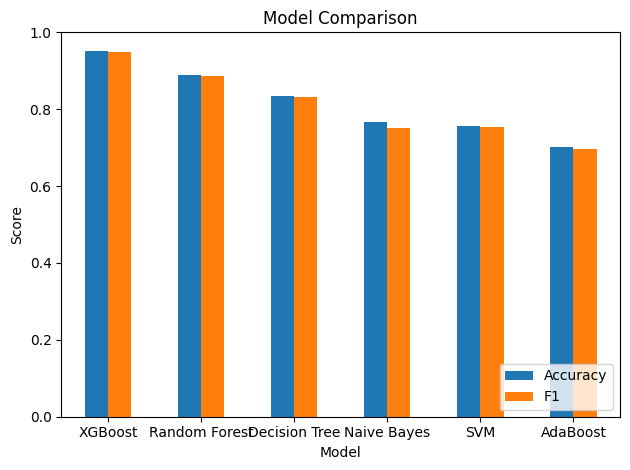

In [17]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.svm import SVC
from sklearn.naive_bayes import GaussianNB
from sklearn.ensemble import RandomForestClassifier, AdaBoostClassifier
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from xgboost import XGBClassifier
import joblib
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix,
)

# Encode activity labels
le = LabelEncoder()
feature_df["activity"] = le.fit_transform(feature_df["activity"])


X = feature_df[feature_cols]
y = feature_df["activity"]

# Stratified train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y,
)

# Standardize features
scaler=StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

joblib.dump(scaler, "scaler.joblib")

# Define models with fixed random states for reproducibility
models = {
    "Decision Tree": DecisionTreeClassifier(max_depth=10, random_state=42),
    "SVM": SVC(kernel="rbf", C=1.0, gamma="scale", probability=True, random_state=42),
    "Naive Bayes": GaussianNB(),
    "Random Forest": RandomForestClassifier(n_estimators=100, max_depth=12, random_state=42),
    "AdaBoost": AdaBoostClassifier(n_estimators=100, random_state=42),
    "XGBoost": XGBClassifier(
        objective="multi:softprob",
        eval_metric="mlogloss",
        use_label_encoder=False,
        n_estimators=100,
        max_depth=6,
        learning_rate=0.1,
        random_state=42,
    )
}
    

results = []

for name, model in models.items():
    print(f"\n=== {name} ===")

    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)

    accuracy = accuracy_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred, average="macro", zero_division=0)
    recall = recall_score(y_test, y_pred, average="macro", zero_division=0)
    f1 = f1_score(y_test, y_pred, average="macro", zero_division=0)

    print(f"Accuracy: {accuracy:.4f}")
    print(f"Precision (macro): {precision:.4f}")
    print(f"Recall (macro): {recall:.4f}")
    print(f"F1 (macro): {f1:.4f}")
    print(classification_report(y_test, y_pred, zero_division=0))

    cm = confusion_matrix(y_test, y_pred)
    cm_df = pd.DataFrame(cm, index=model.classes_, columns=model.classes_)
    display(cm_df)

    results.append(
        {
            "Model": name,
            "Accuracy": accuracy,
            "Precision": precision,
            "Recall": recall,
            "F1": f1,
        }
    )

results_df = pd.DataFrame(results).set_index("Model").sort_values(by="Accuracy", ascending=False)

print("\n=== Model Summary ===")
display(results_df)

plt.figure(figsize=(8, 5))
results_df[["Accuracy", "F1"]].plot(kind="bar", ylim=(0, 1), rot=0)
plt.title("Model Comparison")
plt.ylabel("Score")
plt.legend(loc="lower right")
plt.tight_layout()
plt.show()

In [3]:
import numpy as np


windows = []
window_labels = []

labels = data['activity'].values if 'activity' in data.columns else None

for start in range(0, len(data) - window_size + 1, step_size):
    window = data.iloc[start:start + window_size, :].values  
    windows.append(window)
    if labels is not None:
        window_label = labels[start:start + window_size]
        # Use the most frequent label in the window
        if np.issubdtype(window_label.dtype, np.integer):
            window_labels.append(np.bincount(window_label).argmax())
        else:
            window_labels.append(max(set(window_label), key=list(window_label).count))

# Stack all windows into a single 3D array: [num_windows, window_size, n_features]
X_dl = np.stack(windows)
y_dl = np.array(window_labels) if window_labels else None
# Now X_dl has shape [num_windows, window_size, n_features]
for axis in range(X_dl.shape[2]):
    plt.figure(figsize=(12, 4))
    for i in range(min(5, X_dl.shape[0])):  # Plot first 5 windows
        plt.plot(X_dl[i, :, axis], alpha=0.7)
    plt.title(f"Feature {axis} across windows")
    plt.xlabel("Time Steps")
    plt.ylabel(f"Feature {axis} Value")
    plt.tight_layout()
    plt.show()

print("Shape of deep learning input:", X_dl.shape)
if y_dl is not None:
    print("Shape of deep learning labels:", y_dl.shape)


/workspaces/CS156-Intro-To-AI-Project/venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


/workspaces/CS156-Intro-To-AI-Project/venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


NameError: name 'pd' is not defined

To identify behavioral patterns and detect changes in activity over time, six machine learning classifiers were trained and evaluated on features extracted from wearable sensor data: Decision Tree, Support Vector Machine (SVM), Naive Bayes, Random Forest, AdaBoost, and XGBoost. Each model was trained on seven time-domain and frequency-domain features — mean, standard deviation, RMS, zero-crossing rate, dominant frequency, spectral energy, and spectral entropy — extracted from 3-second sliding windows with 50% overlap. A stratified train-test split was used to ensure balanced class representation across all seven activity classes.

XGBoost significantly outperformed all other models, achieving 88.5% accuracy and a macro F1 score of 86.3%, with strong and consistent performance across all seven activity classes. Decision Tree and Random Forest formed a second tier at around 74%, while SVM, Naive Bayes, and AdaBoost lagged behind.

XGBoost's strength comes from its ability to capture complex, non-linear relationships between features, making it the most reliable classifier for identifying what behavior is occurring at any given moment. However, since all classical models evaluate each window in isolation — with no memory of prior windows — they are limited in their ability to model the sequence of behaviors over time. Detecting when and how behavior changes requires a model that understands temporal context.

To address this, the data was also prepared as a 3D windowed tensor (21 samples × 123 time steps × 54 features) as input for deep learning models in the next section. The 54 features were examined across 123 time steps to assess their usefulness before deep learning training. Not all features carry meaningful signal. Some, like Feature 0, simply encode user identity and should be removed to prevent the model from learning who the person is rather than what they are doing. Feature 1 is the most valuable, clearly showing the exact points where a person transitions from one activity to another — which is precisely what the project aims to detect. Features in the middle range, roughly 2 through 30, are noisier but still capture useful information about how a person is moving. Feature 40 stands out as clean and well-structured, likely representing overall movement intensity, and is expected to be among the most informative for the deep learning model. Features like Feature 53 contribute almost no signal and are candidates for removal.

__7. Advanced Modeling & Evaluation__

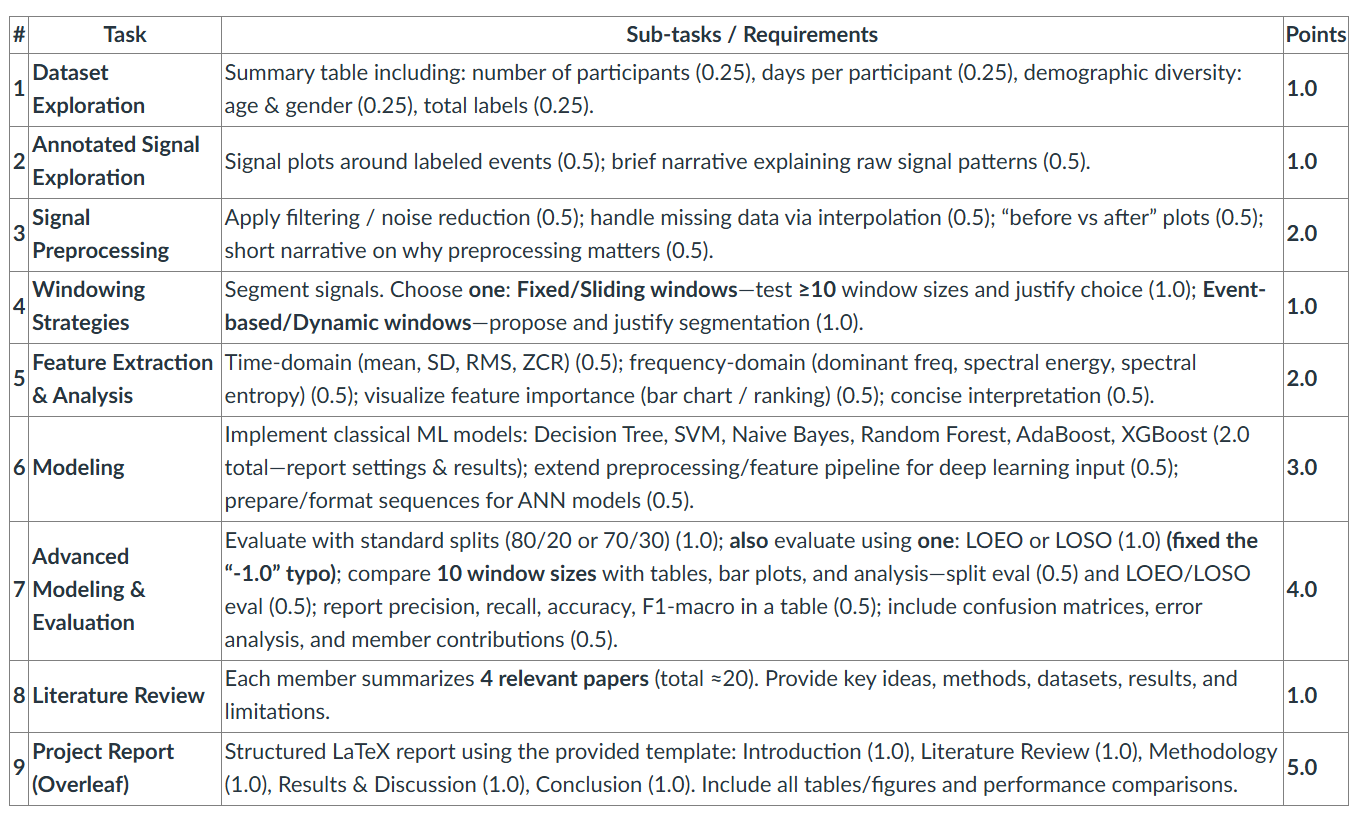